In [1]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt

In [2]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:
        # MEAN FILTER
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    mean = np.sum(region) / area
                    canvas[i, j] = mean

        # case 'mean':
        #     area = size * size
        #     for i in range(height):
        #         for j in range(width):
        #             # Inisialisasi nilai jumlah awal
        #             total_sum = 0
                    
        #             # Looping untuk menjumlahkan piksel di dalam area filter (size x size)
        #             for m in range(size):
        #                 for n in range(size):
        #                     # Mengambil nilai langsung dari matriks 'padded'
        #                     total_sum += padded[i + m, j + n]
                    
        #             # Menghitung rata-rata (mean)
        #             mean = total_sum / area
        #             canvas[i, j] = mean

        # MEDIAN FILTER
        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    median = np.median(region)
                    canvas[i, j] = median

        # case 'median':
        #     area = size * size
        #     mid_index = area // 2
        #     is_even = (area % 2 == 0)
            
        #     for i in range(height):
        #         for j in range(width):
        #             # 1. Siapkan list kosong untuk menampung nilai piksel
        #             values = []
                    
        #             # 2. Ambil setiap nilai piksel di area (size x size)
        #             for m in range(size):
        #                 for n in range(size):
        #                     values.append(padded[i + m, j + n])
                    
        #             # 3. Urutkan list dari yang terkecil hingga terbesar
        #             values.sort()
                    
        #             # 4. Tentukan nilai median berdasarkan jumlah elemen (ganjil/genap)
        #             if is_even:
        #                 # Jika total piksel genap, ambil rata-rata dua nilai di tengah
        #                 median = (values[mid_index - 1] + values[mid_index]) / 2.0
        #             else:
        #                 # Jika total piksel ganjil, langsung ambil nilai yang tepat di tengah
        #                 median = values[mid_index]
                        
        #             canvas[i, j] = median

        # MODE / MODUS FILTER
        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i, j] = mode_val

        # case 'modus':
        #     for i in range(height):
        #         for j in range(width):
        #             count = {}
                    
        #             # 1. Menghitung frekuensi nilai piksel tanpa region.ravel()
        #             for m in range(size):
        #                 for n in range(size):
        #                     val = padded[i + m, j + n]
                            
        #                     # Memasukkan atau menambah hitungan ke dalam dictionary
        #                     if val in count:
        #                         count[val] += 1
        #                     else:
        #                         count[val] = 1
                    
        #             max_count = 0
        #             mode_val = 0
                    
        #             # 2. Mencari frekuensi tertinggi tanpa count.items()
        #             for val in count:
        #                 # Mengakses jumlah frekuensi menggunakan key (val)
        #                 freq = count[val] 
                        
        #                 if freq > max_count:
        #                     max_count = freq
        #                     mode_val = val
                            
        #             canvas[i, j] = mode_val

    return canvas

# cara panggil / how to call
# hasil = filter(foto_karin, 3, 'mean')

def convolution(img, kernel):
    # ukuran kernel / kernel size
    size = kernel.shape[0]
    
    # ukuran padding / padding size
    pad_size = size // 2
    
    # tambah padding nol / add zero padding
    padded = np.pad(img, pad_size, mode='constant')
    
    # kanvas hasil / output canvas
    canvas = np.zeros_like(img).astype(np.float32)
    
    # dimensi gambar / image dimensions
    height, width = img.shape
    
    # loop baris / loop rows
    for i in range(height):
        # loop kolom / loop columns
        for j in range(width):
            # area kernel / kernel region
            region = padded[i:i+size, j:j+size]
            
            # hitung konvolusi / compute convolution
            canvas[i, j] = np.sum(region * kernel)
            
    # kembalikan gambar / return image
    return canvas

# cara panggil / how to call
# hasil = convolution(fotoMarsha, kernel)

def edge(img, kernelx, kernely):
    # konvolusi sumbu x / x-axis convolution
    gx = convolution(img, kernelx)
    
    # konvolusi sumbu y / y-axis convolution
    gy = convolution(img, kernely)
    
    # kanvas kosong / empty canvas
    canvas = np.zeros_like(img, dtype=np.float32)
    
    # gabung gradien absolut / combine absolute gradients
    canvas = np.abs(gx) + np.abs(gy)
    
    # normalisasi ke-255 / normalize to 0-255
    canvas = canvas * 255.0 / np.max(canvas)
    
    # batas nilai dan konversi / clip values and convert
    return np.clip(canvas, 0, 255).astype(np.uint8)

# cara panggil / how to call
# hasil_tepi = edge(fotoTania, prewittx, prewitty)

# def normalize(image):
    image = image.astype(np.float32)
    return (image * 255.0 / np.max(image)).astype(np.uint8)

def to_uint8(img):
    return np.clip(img, 0, 255).astype(np.uint8)

def normalize(img):
    mn, mx = img.min(), img.max()
    if mx == mn:
        return np.zeros_like(img, dtype=np.uint8)
    return to_uint8((img - mn) / (mx - mn) * 255)

def threshold_edge(img, threshold):
    canvas = np.zeros_like(img)

    canvas[img >= threshold] = 255
    canvas[img < threshold] = 0

    return canvas.astype(np.uint8)


In [3]:
# kernel penghalus gambar / image smoothing kernel
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

# kernel penajam gambar / image sharpening kernel
kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

# kernel sobel sumbu x / x-axis sobel kernel
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

# kernel sobel sumbu y / y-axis sobel kernel
sobelY = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

# kernel prewitt sumbu x / x-axis prewitt kernel
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

# kernel prewitt sumbu y / y-axis prewitt kernel
prewittY = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

# The document contains the following under "Roberts Kernel" (Duplicate of Sobel):
# kernel roberts (labeled as sobel in the document)
robertsX = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

robertsY = np.array([
    [ 0, 1],
    [-1, 0]
], dtype=np.float32)

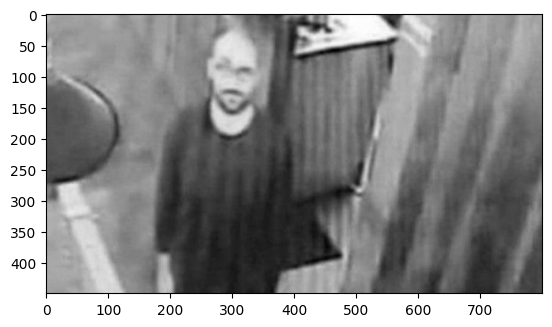

In [4]:
orangJelek = cv2.imread('Assets/backup.jpg', cv2.IMREAD_GRAYSCALE)
david = cv2.imread('Assets/david.jpg', cv2.IMREAD_GRAYSCALE)
hachimi = cv2.imread('Assets/hachimi.jpg', cv2.IMREAD_GRAYSCALE)
mambo = cv2.imread('Assets/mambo.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(orangJelek, cmap='gray')
plt.show()

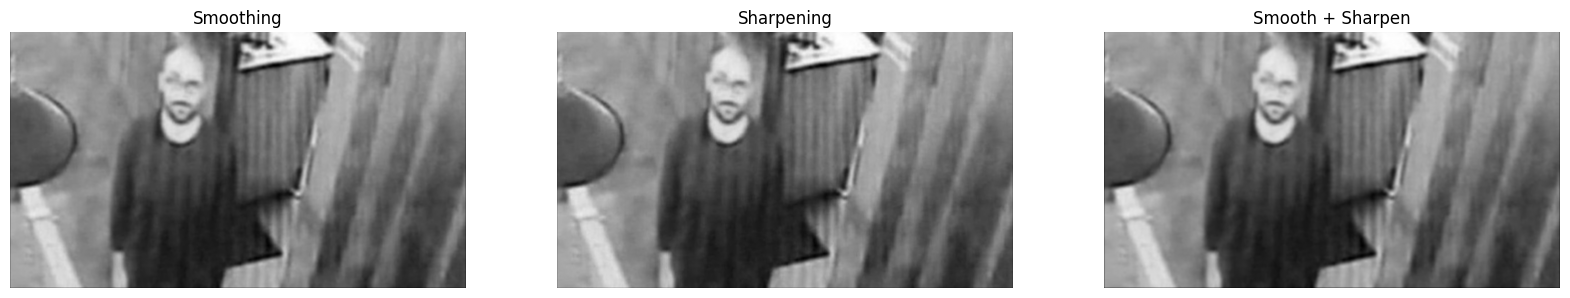

In [5]:
smoothing_backup = convolution(orangJelek, kernelSmoothing)
sharpening_backup = convolution(orangJelek, kernelSharpening)
smoothsharp_backup = convolution(smoothing_backup, kernelSharpening)

plt.figure(figsize=(20, 9))

plt.subplot(1, 3, 1)
plt.imshow(smoothing_backup, cmap='gray')
plt.title('Smoothing')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sharpening_backup, cmap='gray')
plt.title('Sharpening')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(smoothsharp_backup, cmap='gray')
plt.title('Smooth + Sharpen')
plt.axis('off')

plt.show()


Berdasarkan pengelihatan saya perbedaan dari ketiga gambar diatas sama saja, secara teori. Smoothing seharusnya membuat gambar lebih halus, Sharpening membuat gambar menjadi lebih tajam, dan Smoothing+Sharpening seharusnya sih membuat gamabr lebih halus dan mengurangi noise, kemudian hasil gambar tersebut dipertajam dan menegaskan edge objeknya :[]

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

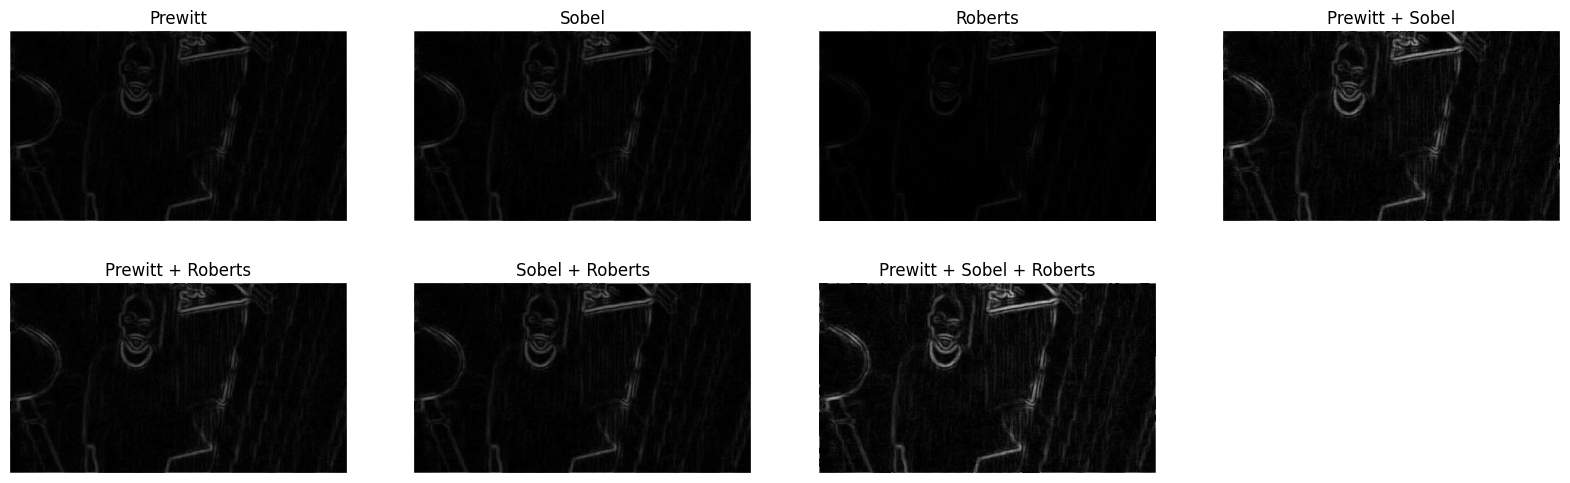

In [6]:
prewitBackup = edge(orangJelek, prewittX, prewittY)

sobelBackup = edge(orangJelek, sobelX, sobelY)

robertsBackup = edge(orangJelek, robertsX, robertsY)

# prewitsobelBackup = edge(prewitBackup, sobelX, sobelY)
prewitsobelBackup1 = normalize(prewitBackup + sobelBackup)

# prewitrobertsBackup = edge(prewitBackup, robertsX, robertsY)
prewitrobertsBackup1 = normalize(prewitBackup + robertsBackup)

# sobelrobertsBackup = edge(sobelBackup, robertsX, robertsY)
sobelrobertsBackup1 = normalize(sobelBackup + robertsBackup)

# prewitsobelrobertsBackup = edge(prewitsobelBackup, robertsX, robertsY)
prewitsobelrobertsBackup1 = normalize(prewitBackup + sobelBackup + robertsBackup)

plt.figure(figsize=(20, 6))
plt.subplot(2, 4, 1)
plt.imshow(prewitBackup, cmap='gray')
plt.title('Prewitt')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(sobelBackup, cmap='gray')
plt.title('Sobel')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(robertsBackup, cmap='gray')
plt.title('Roberts')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(prewitsobelBackup1, cmap='gray')
plt.title('Prewitt + Sobel')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(prewitrobertsBackup1, cmap='gray')
plt.title('Prewitt + Roberts')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(sobelrobertsBackup1, cmap='gray')
plt.title('Sobel + Roberts')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(prewitsobelrobertsBackup1, cmap='gray')   
plt.title('Prewitt + Sobel + Roberts')
plt.axis('off')


Operator yang digunakan memiliki fungsi yang berbeda-beda. seinget saya sih ada yang bagus di vertikal atau horizontalnya gitu tapi gatau yg mana jadi. Terus ada yang operator yang di gabungkan, nah seharunysa itu bisa ngebuat deteksi edge lebih baik karena misal yang horizontal sama vertikal itu digabung 

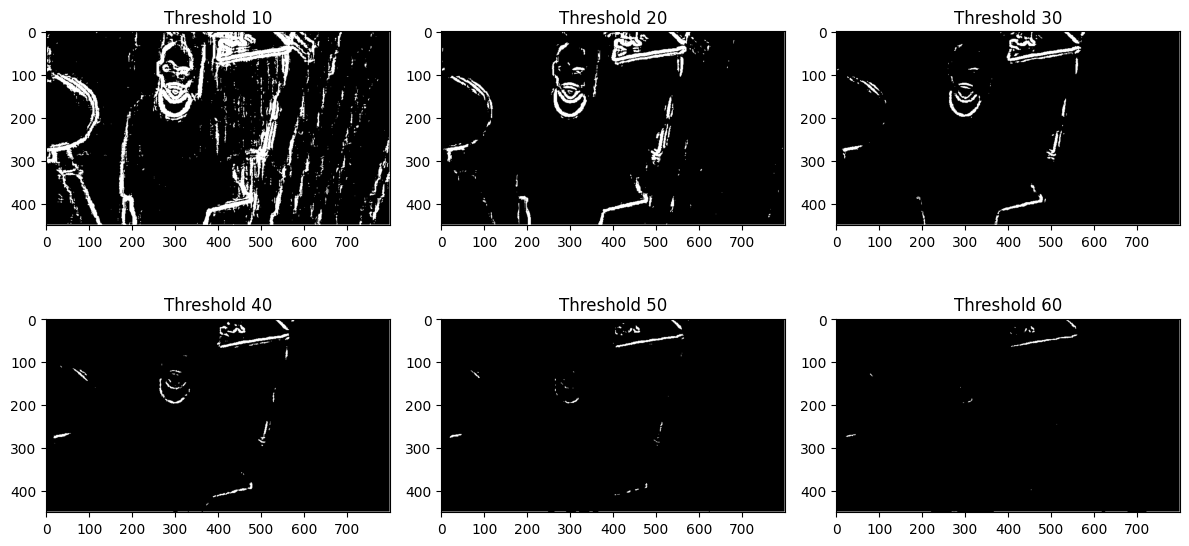

In [7]:
sobelBackupMean = filter(sobelBackup, 9, 'median')

Threshold10 = threshold_edge(sobelBackup, 10)
Threshold20 = threshold_edge(sobelBackup, 20)
Threshold30 = threshold_edge(sobelBackup, 30)
Threshold40 = threshold_edge(sobelBackup, 40)
Threshold50 = threshold_edge(sobelBackup, 50)
Threshold60 = threshold_edge(sobelBackup, 60)

plt.figure(figsize=(12, 6))

plt.subplot(2, 3, 1)
plt.title("Threshold 10")
plt.imshow(Threshold10, cmap='gray')

plt.subplot(2, 3, 2)
plt.title("Threshold 20")
plt.imshow(Threshold20, cmap='gray')

plt.subplot(2, 3, 3)
plt.title("Threshold 30")
plt.imshow(Threshold30, cmap='gray')

plt.subplot(2, 3, 4)
plt.title("Threshold 40")
plt.imshow(Threshold40, cmap='gray')

plt.subplot(2, 3, 5)
plt.title("Threshold 50")
plt.imshow(Threshold50, cmap='gray')

plt.subplot(2, 3, 6)
plt.title("Threshold 60")
plt.imshow(Threshold60, cmap='gray')

plt.tight_layout()
plt.show()

Threshold sangat berpengaruh pada komposisi warna gelap dan cerah yang akan muncul. Threshold rendah menghasilkan lebih banyak warna putih, kemudian threshold tinggi menghasilkan warna putih yang lebih sedikit.

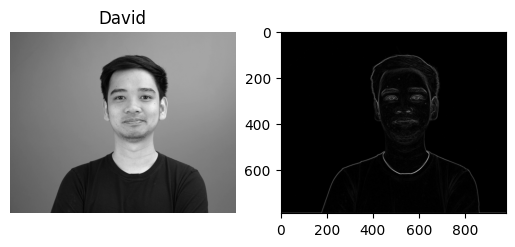

In [10]:
david = cv2.imread('Assets/david.jpg', cv2.IMREAD_GRAYSCALE)
plt.subplot(1, 2, 1)
plt.imshow(david, cmap='gray')
plt.title('David')
plt.axis('off')

david = convolution(david, kernelSmoothing)

plt.subplot(1, 2, 2)
davidEdge = edge(david, sobelX, sobelY)
plt.imshow(davidEdge, cmap='gray')




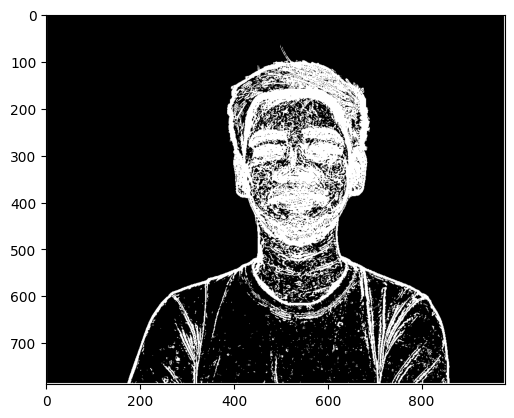

In [9]:
Threshold10David = threshold_edge(davidEdge, 5)
plt.imshow(Threshold10David, cmap='gray')